In [11]:
import pandas as pd

usage = pd.read_csv(f"Data Generator/dataset/usage_monthly.csv")
tickets = pd.read_csv(f"Data Generator/dataset/support_tickets_monthly.csv")
renewals = pd.read_csv(f"Data Generator/dataset/renewals.csv")
companies = pd.read_csv(f"Data Generator/dataset/companies.csv")
contracts = pd.read_csv(f"Data Generator/dataset/contracts.csv")

print("Monthly Usage\n",usage.head())
print("\n\nMonthly Support Tickets\n",tickets.head())
print("\n\nRenewals\n",renewals.head())
print("\n\nCompanies\n",companies.head())
print("\n\nContracts\n",contracts.head())

Monthly Usage
    contract_id  month_index  logins_total  active_users  leads_created  \
0            0            0            72             8             32   
1            0            1            40             8              0   
2            0            2            72             8              8   
3            0            3            40             8             16   
4            0            4            72             8              8   

   opportunities_created  reports_generated  feature_adoption_score  
0                     15                 16                0.390718  
1                      0                 16                0.390718  
2                      2                 16                0.390718  
3                     10                 24                0.390718  
4                      2                  8                0.390718  


Monthly Support Tickets
    contract_id  month_index  ticket_count  avg_resolution_hours  csat_score  \
0            0

In [3]:
# Aggregate usage
usage_agg = usage.groupby("contract_id").agg({
    "logins_total": "mean",
    "active_users": "mean",
    "feature_adoption_score": "mean"
}).reset_index()

# Aggregate tickets
tickets_agg = tickets.groupby("contract_id").agg({
    "ticket_count": "mean",
    "avg_resolution_hours": "mean",
    "csat_score": "mean"
}).reset_index()

# Merge everything
df = contracts.merge(usage_agg, on="contract_id") \
              .merge(tickets_agg, on="contract_id") \
              .merge(renewals, on="contract_id")

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   contract_id             5000 non-null   int64  
 1   company_id              5000 non-null   int64  
 2   company_size            5000 non-null   int64  
 3   industry                5000 non-null   object 
 4   region                  3139 non-null   object 
 5   growth_rate             5000 non-null   float64
 6   annual_revenue          5000 non-null   float64
 7   sales_process_maturity  5000 non-null   float64
 8   crm_maturity_score      5000 non-null   float64
 9   seats_start_x           5000 non-null   int64  
 10  plan_tier               5000 non-null   object 
 11  price_per_seat          5000 non-null   int64  
 12  discount_pct            5000 non-null   float64
 13  contract_value          5000 non-null   float64
 14  duration_months         5000 non-null   

contract_id                  0
company_id                   0
company_size                 0
industry                     0
region                    1861
growth_rate                  0
annual_revenue               0
sales_process_maturity       0
crm_maturity_score           0
seats_start_x                0
plan_tier                    0
price_per_seat               0
discount_pct                 0
contract_value               0
duration_months              0
logins_total_x               0
active_users_x               0
feature_adoption_score       0
ticket_count                 0
avg_resolution_hours         0
csat_score                   8
seats_start_y                0
logins_total_y               0
active_users_y               0
renewed                      0
seat_change                  0
dtype: int64

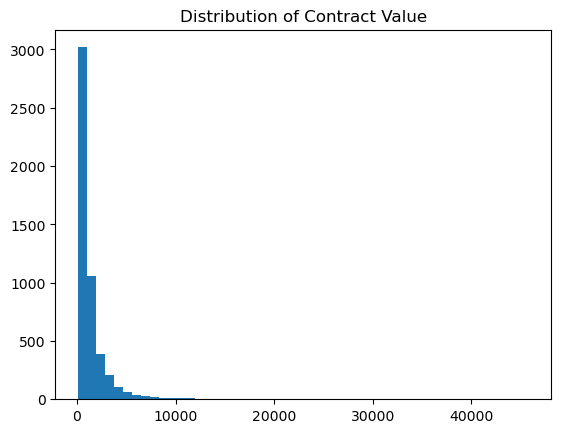

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["contract_value"], bins=50)
plt.title("Distribution of Contract Value")
plt.show()

In [12]:
import numpy as np

df.groupby("renewed")["logins_total_x"].mean()

renewed
0     54.051176
1    150.988663
Name: logins_total_x, dtype: float64

In [13]:
df.groupby("renewed")["feature_adoption_score"].mean()

renewed
0    0.432916
1    0.529705
Name: feature_adoption_score, dtype: float64

In [18]:
df.groupby("renewed")["csat_score"].mean()

renewed
0    3.530435
1    3.465830
Name: csat_score, dtype: float64

In [17]:
df.groupby("renewed")["ticket_count"].mean()

renewed
0    1.613193
1    4.540506
Name: ticket_count, dtype: float64

In [19]:
df.groupby("renewed")["seat_change"].mean()

renewed
0    2.582358
1    5.080129
Name: seat_change, dtype: float64

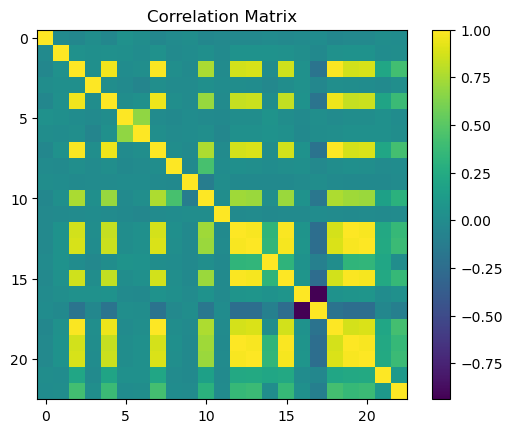

In [20]:
corr = df.select_dtypes(include=np.number).corr()

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split

features = [
    "logins_total_x",
    "active_users_x",
    "feature_adoption_score",
    "ticket_count",
    "avg_resolution_hours",
    "csat_score",
    "seat_change"
]

X = df[features].fillna(df[features].mean())
y = df["renewed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)

accuracy_score(y_test, preds)

0.756

In [27]:
pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

,feature,coefficient
3,ticket_count,0.173100
1,active_users_x,0.093809
2,feature_adoption_score,0.084703
6,seat_change,0.006941
0,logins_total_x,-0.000477
4,avg_resolution_hours,-0.016518
5,csat_score,-0.042292
